In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("play_tennis_dataset.csv")
df=pd.DataFrame(data)

In [3]:

df.dropna(inplace=True)

In [4]:
df.isnull().sum()

Day            0
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play           0
dtype: int64

In [5]:
df.shape

(5425, 6)

In [6]:
df=df.drop('Day',axis=1)


In [7]:
print(df.columns)


Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play'], dtype='object')


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
Outlook=LabelEncoder()
Temperature=LabelEncoder() 
Humidity=LabelEncoder()
Wind=LabelEncoder()
Play=LabelEncoder()

In [10]:
df['Outlook']=Outlook.fit_transform(df['Outlook'])
df['Temperature']=Outlook.fit_transform(df['Temperature'])
df['Humidity']=Outlook.fit_transform(df['Humidity'])
df['Wind']=Outlook.fit_transform(df['Wind'])
df['Play']=Outlook.fit_transform(df['Play'])

In [11]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
x_train.shape

(4340, 4)

In [15]:
y_train.shape

(4340,)

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
classifier=DecisionTreeClassifier(criterion='gini')
#classifier=DecisionTreeClassifier(criterion='entropy')

In [29]:
classifier.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [30]:
pred=classifier.predict(x_test)
pred

array([1, 0, 1, ..., 1, 1, 1], shape=(1085,))

In [31]:
x_test

,Outlook,Temperature,Humidity,Wind
935,0,0,0,1
1442,1,0,0,0
4048,2,2,1,1
1873,0,1,1,1
3760,0,1,1,1
...,...,...,...,...
629,2,1,1,1
3433,2,2,0,0
5852,2,0,1,1
2183,0,2,1,1


In [32]:
classifier.score(x_test,y_test)*100

89.86175115207374

In [33]:
from sklearn import tree

[Text(0.3706395348837209, 0.9285714285714286, 'x[0] <= 0.5\ngini = 0.444\nsamples = 4340\nvalue = [1443, 2897]'),
 Text(0.1511627906976744, 0.7857142857142857, 'x[2] <= 0.5\ngini = 0.151\nsamples = 1524\nvalue = [125, 1399]'),
 Text(0.26090116279069764, 0.8571428571428572, 'True  '),
 Text(0.06976744186046512, 0.6428571428571429, 'x[1] <= 0.5\ngini = 0.283\nsamples = 605\nvalue = [103, 502]'),
 Text(0.046511627906976744, 0.5, 'gini = 0.0\nsamples = 253\nvalue = [0, 253]'),
 Text(0.09302325581395349, 0.5, 'x[1] <= 1.5\ngini = 0.414\nsamples = 352\nvalue = [103, 249]'),
 Text(0.046511627906976744, 0.35714285714285715, 'x[3] <= 0.5\ngini = 0.487\nsamples = 153\nvalue = [89, 64]'),
 Text(0.023255813953488372, 0.21428571428571427, 'gini = 0.0\nsamples = 45\nvalue = [45, 0]'),
 Text(0.06976744186046512, 0.21428571428571427, 'gini = 0.483\nsamples = 108\nvalue = [44, 64]'),
 Text(0.13953488372093023, 0.35714285714285715, 'x[3] <= 0.5\ngini = 0.131\nsamples = 199\nvalue = [14, 185]'),
 Text(0.

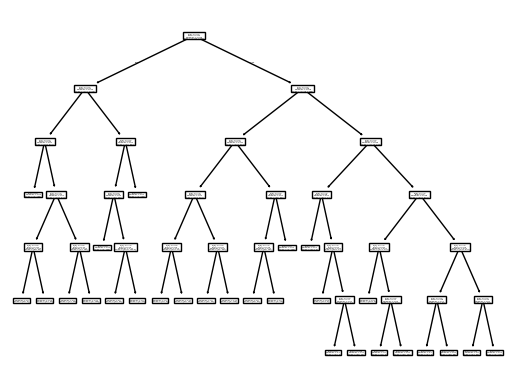

In [34]:
tree.plot_tree(classifier)